--- Processing simulated_gain_spectra.csv ---
Maxima found in simulated_gain_spectra.csv:
  [Gain_Sim_2.00mA] Peak Wavelength: 1293.663 nm, Value: 5.247e-06
  [Gain_Sim_4.00mA] Peak Wavelength: 1293.663 nm, Value: 7.380e-06
  [Gain_Sim_6.00mA] Peak Wavelength: 1293.663 nm, Value: 8.499e-06
  [Gain_Sim_6.00mA] Peak Wavelength: 1189.675 nm, Value: 2.961e-06
  [Gain_Sim_8.00mA] Peak Wavelength: 1293.663 nm, Value: 9.240e-06
  [Gain_Sim_8.00mA] Peak Wavelength: 1189.675 nm, Value: 4.957e-06
  [Gain_Sim_10.00mA] Peak Wavelength: 1293.663 nm, Value: 9.789e-06
  [Gain_Sim_10.00mA] Peak Wavelength: 1189.675 nm, Value: 6.317e-06

--- Processing wpd_datasets.csv ---


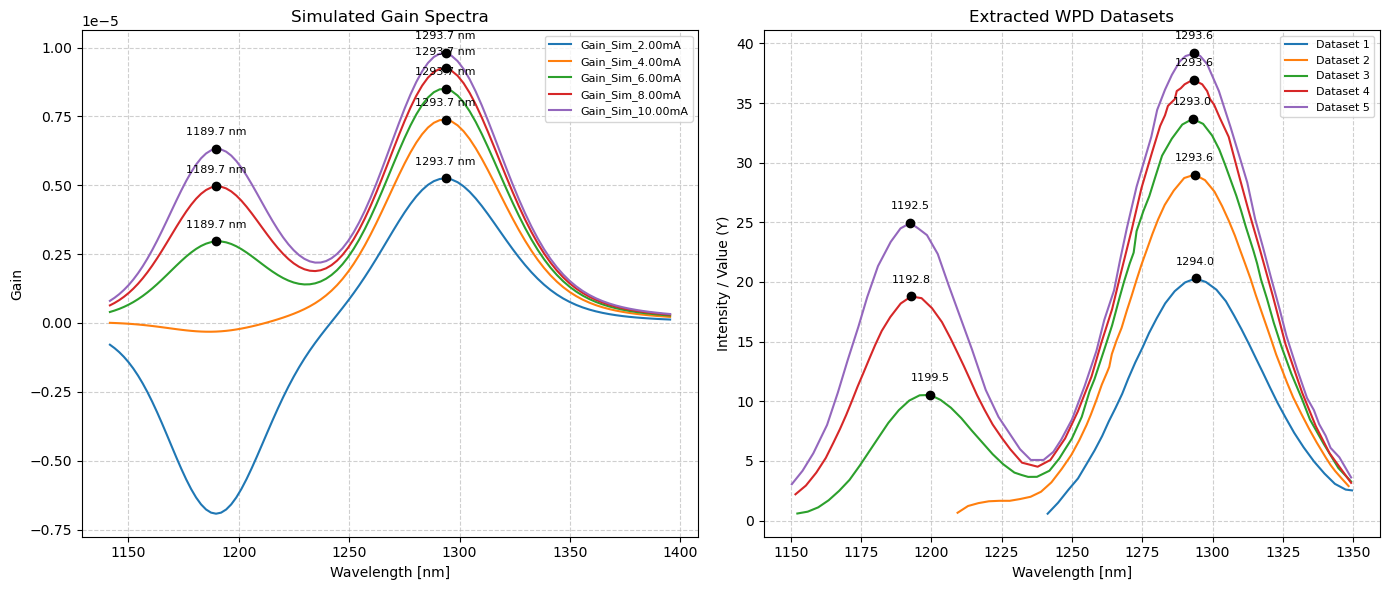

Maxima found in wpd_datasets.csv:
  [Dataset 1] Peak X (Wavelength): 1293.967 nm, Peak Y: 20.297
  [Dataset 2] Peak X (Wavelength): 1293.630 nm, Peak Y: 28.996
  [Dataset 3] Peak X (Wavelength): 1199.539 nm, Peak Y: 10.529
  [Dataset 3] Peak X (Wavelength): 1292.955 nm, Peak Y: 33.674
  [Dataset 4] Peak X (Wavelength): 1192.794 nm, Peak Y: 18.787
  [Dataset 4] Peak X (Wavelength): 1293.554 nm, Peak Y: 36.907
  [Dataset 5] Peak X (Wavelength): 1192.509 nm, Peak Y: 24.944
  [Dataset 5] Peak X (Wavelength): 1293.554 nm, Peak Y: 39.165


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
# 1. PROCESS THE FIRST FILE: simulated_gain_spectra.csv
# ==========================================
print("--- Processing simulated_gain_spectra.csv ---")
df_sim = pd.read_csv('simulated_gain_spectra.csv')

# The first column is wavelength, subsequent columns are gain at different currents
wavelengths_sim = df_sim.iloc[:, 0].values
gain_columns = df_sim.columns[1:]

sim_peaks_results = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for col in gain_columns:
    gain_values = df_sim[col].values
    
    # Plot the full curve
    ax1.plot(wavelengths_sim, gain_values, label=col)
    
    # Find local maxima (peaks) for this curve
    # distance parameter can be adjusted depending on resolution density
    peak_indices, _ = find_peaks(gain_values, distance=10)
    
    if len(peak_indices) > 0:
        # Find the absolute global maximum or all distinct peaks
        for p_idx in peak_indices:
            peak_wl = wavelengths_sim[p_idx]
            peak_val = gain_values[p_idx]
            sim_peaks_results.append((col, peak_wl, peak_val))
            # Mark on plot
            ax1.scatter(peak_wl, peak_val, color='black', zorder=5)
            ax1.annotate(f"{peak_wl:.1f} nm", (peak_wl, peak_val), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

ax1.set_title('Simulated Gain Spectra')
ax1.set_xlabel('Wavelength [nm]')
ax1.set_ylabel('Gain')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.6)

# Print out simulated peaks
print("Maxima found in simulated_gain_spectra.csv:")
for current_label, wl, val in sim_peaks_results:
    print(f"  [{current_label}] Peak Wavelength: {wl:.3f} nm, Value: {val:.3e}")


# ==========================================
# 2. PROCESS THE SECOND FILE: wpd_datasets.csv
# ==========================================
print("\n--- Processing wpd_datasets.csv ---")
df_wpd = pd.read_csv('wpd_datasets.csv')

col_pairs = []
i = 0
while i < len(df_wpd.columns) - 1:
    x_col = df_wpd.columns[i]
    y_col = df_wpd.columns[i+1]
    col_pairs.append((x_col, y_col))
    i += 2

wpd_peaks_results = []

for idx, (x_col, y_col) in enumerate(col_pairs):
    # Extract columns and drop missing values
    subset = df_wpd[[x_col, y_col]].dropna()
    if subset.empty:
        continue
        
    # Force conversion to numeric, coercing any stray text strings ('X', 'Y', etc.) into NaN
    x_vals = pd.to_numeric(subset.iloc[:, 0], errors='coerce')
    y_vals = pd.to_numeric(subset.iloc[:, 1], errors='coerce')
    
    # Drop rows that failed conversion
    valid_data = pd.DataFrame({'x': x_vals, 'y': y_vals}).dropna()
    if valid_data.empty:
        continue
        
    x_vals = valid_data['x'].values
    y_vals = valid_data['y'].values
    
    # Sort by X to ensure smooth plotting
    sort_idx = np.argsort(x_vals)
    x_vals = x_vals[sort_idx]
    y_vals = y_vals[sort_idx]
    
    dataset_label = f"Dataset {idx+1}"
    
    ax2.plot(x_vals, y_vals, label=dataset_label)
    
    # Find local maxima on the experimental/extracted points safely now that data is clean float64
    peak_indices, _ = find_peaks(y_vals, distance=5)
    
    if len(peak_indices) > 0:
        for p_idx in peak_indices:
            peak_x = x_vals[p_idx]
            peak_y = y_vals[p_idx]
            wpd_peaks_results.append((dataset_label, peak_x, peak_y))
            ax2.scatter(peak_x, peak_y, color='black', zorder=5)
            ax2.annotate(f"{peak_x:.1f}", (peak_x, peak_y), 
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

ax2.set_title('Extracted WPD Datasets')
ax2.set_xlabel('Wavelength [nm]')
ax2.set_ylabel('Intensity / Value (Y)')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print out WPD peaks
print("Maxima found in wpd_datasets.csv:")
for d_label, x_val, y_val in wpd_peaks_results:
    print(f"  [{d_label}] Peak X (Wavelength): {x_val:.3f} nm, Peak Y: {y_val:.3f}")

In [5]:
print((1192.5+1192.8+1199.5)/3-1189.7)

5.2333333333333485


=== FWHM Analysis for Simulated Gain Spectra ===
  [Gain_Sim_2.00mA] Peak at 1293.66 nm | FWHM: 59.04 nm
  [Gain_Sim_4.00mA] Peak at 1293.66 nm | FWHM: 60.62 nm
  [Gain_Sim_6.00mA] Peak at 1293.66 nm | FWHM: 60.47 nm
  [Gain_Sim_6.00mA] Peak at 1189.67 nm | FWHM: 36.87 nm
  [Gain_Sim_8.00mA] Peak at 1293.66 nm | FWHM: 59.74 nm
  [Gain_Sim_8.00mA] Peak at 1189.67 nm | FWHM: 39.73 nm
  [Gain_Sim_10.00mA] Peak at 1293.66 nm | FWHM: 59.31 nm
  [Gain_Sim_10.00mA] Peak at 1189.67 nm | FWHM: 40.75 nm

=== FWHM Analysis for WPD Datasets ===
  [Dataset 1] Peak at 1293.97 nm | FWHM: 50.72 nm
  [Dataset 2] Peak at 1293.63 nm | FWHM: 52.42 nm
  [Dataset 3] Peak at 1199.54 nm | FWHM: 34.47 nm
  [Dataset 3] Peak at 1292.96 nm | FWHM: 52.83 nm
  [Dataset 4] Peak at 1192.79 nm | FWHM: 39.55 nm
  [Dataset 4] Peak at 1293.55 nm | FWHM: 53.36 nm
  [Dataset 5] Peak at 1192.51 nm | FWHM: 41.06 nm
  [Dataset 5] Peak at 1293.55 nm | FWHM: 52.91 nm


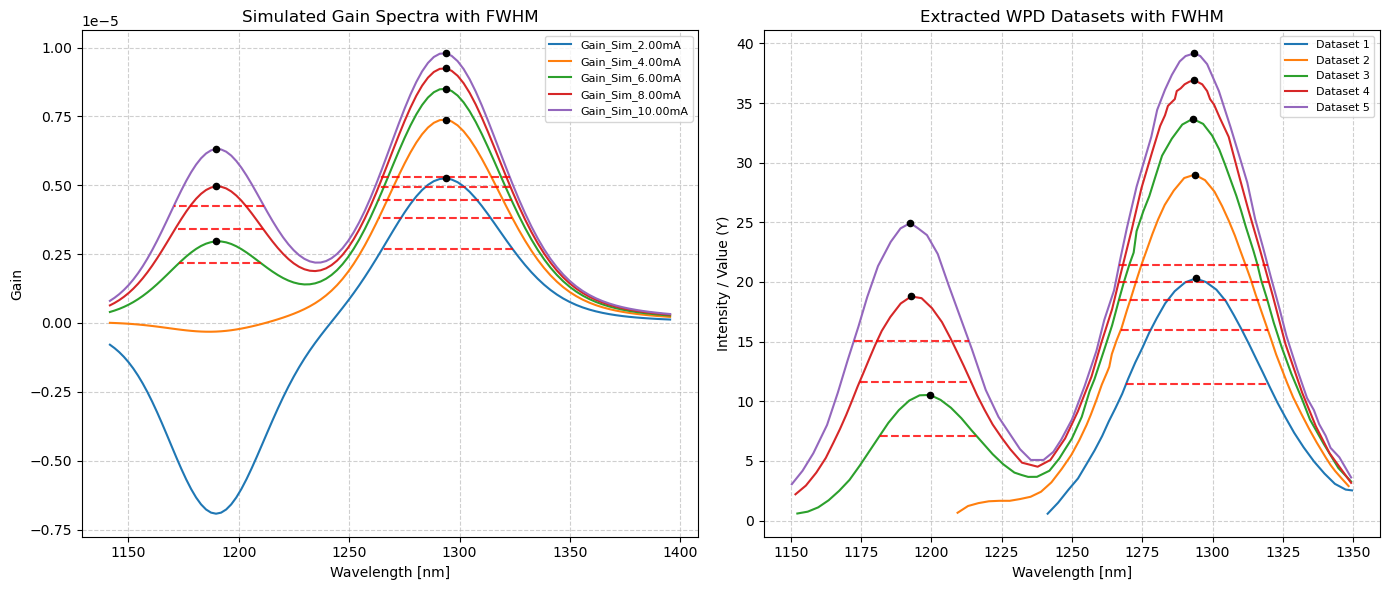

In [6]:
from scipy.signal import peak_widths

# ==========================================
# FWHM CALCULATION AND PLOTTING CELL
# ==========================================

print("=== FWHM Analysis for Simulated Gain Spectra ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Process FWHM for Simulated Spectra
for col in gain_columns:
    gain_values = df_sim[col].values
    ax1.plot(wavelengths_sim, gain_values, label=col)
    
    peak_indices, _ = find_peaks(gain_values, distance=10)
    if len(peak_indices) > 0:
        # Calculate widths at half maximum (rel_height=0.5)
        widths, width_heights, left_ips, right_ips = peak_widths(gain_values, peak_indices, rel_height=0.5)
        
        for idx, p_idx in enumerate(peak_indices):
            peak_wl = wavelengths_sim[p_idx]
            peak_val = gain_values[p_idx]
            
            # Convert index-based interpolation points back to physical X (wavelength) units
            left_wl = np.interp(left_ips[idx], np.arange(len(wavelengths_sim)), wavelengths_sim)
            right_wl = np.interp(right_ips[idx], np.arange(len(wavelengths_sim)), wavelengths_sim)
            fwhm_nm = abs(right_wl - left_wl)
            
            print(f"  [{col}] Peak at {peak_wl:.2f} nm | FWHM: {fwhm_nm:.2f} nm")
            
            # Plot markers and horizontal FWHM span lines
            ax1.scatter(peak_wl, peak_val, color='black', s=20, zorder=5)
            ax1.hlines(width_heights[idx], left_wl, right_wl, color='red', linestyle='--', alpha=0.8)

ax1.set_title('Simulated Gain Spectra with FWHM')
ax1.set_xlabel('Wavelength [nm]')
ax1.set_ylabel('Gain')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.6)


# 2. Process FWHM for WPD Datasets
print("\n=== FWHM Analysis for WPD Datasets ===")
for idx, (x_col, y_col) in enumerate(col_pairs):
    subset = df_wpd[[x_col, y_col]].dropna()
    if subset.empty:
        continue
        
    x_vals = pd.to_numeric(subset.iloc[:, 0], errors='coerce')
    y_vals = pd.to_numeric(subset.iloc[:, 1], errors='coerce')
    valid_data = pd.DataFrame({'x': x_vals, 'y': y_vals}).dropna()
    if valid_data.empty:
        continue
        
    x_vals = valid_data['x'].values
    y_vals = valid_data['y'].values
    
    sort_idx = np.argsort(x_vals)
    x_vals = x_vals[sort_idx]
    y_vals = y_vals[sort_idx]
    
    dataset_label = f"Dataset {idx+1}"
    ax2.plot(x_vals, y_vals, label=dataset_label)
    
    peak_indices, _ = find_peaks(y_vals, distance=5)
    if len(peak_indices) > 0:
        widths, width_heights, left_ips, right_ips = peak_widths(y_vals, peak_indices, rel_height=0.5)
        
        for p_i, p_idx in enumerate(peak_indices):
            peak_x = x_vals[p_idx]
            peak_y = y_vals[p_idx]
            
            left_x = np.interp(left_ips[p_i], np.arange(len(x_vals)), x_vals)
            right_x = np.interp(right_ips[p_i], np.arange(len(x_vals)), x_vals)
            fwhm_x = abs(right_x - left_x)
            
            print(f"  [{dataset_label}] Peak at {peak_x:.2f} nm | FWHM: {fwhm_x:.2f} nm")
            
            ax2.scatter(peak_x, peak_y, color='black', s=20, zorder=5)
            ax2.hlines(width_heights[p_i], left_x, right_x, color='red', linestyle='--', alpha=0.8)

ax2.set_title('Extracted WPD Datasets with FWHM')
ax2.set_xlabel('Wavelength [nm]')
ax2.set_ylabel('Intensity / Value (Y)')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()